# SmartCare Hospital AI - Disease Risk Classification (Option C)
**Coursework Code:** CCS3440 – Artificial Intelligence  
**Target Variable:** `disease_risk_level` (Multi-Class Classification: Low, Medium, High)  

This notebook covers Tasks 02 to 07 for the selected prediction problem. The target is explicitly the disease risk level, and the remaining patient variables are treated as input features after excluding identifiers and known leakage variables.

---


## Task 02: Dataset Understanding

This stage checks the dataset structure, the prediction target, relevant attribute groups, and data quality issues before the model workflow begins.

- `disease_risk_level` is the prediction target.
- Candidate predictors include demographic, clinical, hospital operational, and financial attributes.
- `record_id` and `patient_id` are identifiers and are excluded from prediction.
- `no_show` and `readmitted_30_days` belong to other coursework prediction tasks and are excluded to avoid leakage.
- `room_type` is the major field with missing values and will be handled as a missing category rather than dropped.
- No duplicate records were found in the initial inspection.

### 2.1 Load Dataset and Libraries

The dataset and the supporting data dictionary are loaded first so the attribute meanings can be checked before any modelling step.


In [2]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path("..")
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
MODELS_DIR = PROJECT_ROOT / "models"

for p in [PROCESSED_DATA_DIR, FIGURES_DIR, METRICS_DIR, MODELS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

data_path = RAW_DATA_DIR / "smartcare_ai_dataset_1000.csv"
dict_path = RAW_DATA_DIR / "smartcare_ai_dataset_data_dictionary.csv"

assert data_path.exists(), f"Raw data file not found: {data_path}"
assert dict_path.exists(), f"Data dictionary file not found: {dict_path}"

df = pd.read_csv(data_path)
df_dict = pd.read_csv(dict_path)

print(f"Dataset Shape: {df.shape}")
display(df.head())


Dataset Shape: (1000, 33)


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,0,Completed,0,NaN,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,Paid,Insurance,0,0,High
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,1,Completed,0,NaN,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,1,No-Show,0,NaN,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium
3,4,P10004,44,Female,AB-,Cardiology,Asthma,2025-10-16,16,1,0,Completed,0,NaN,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,Paid,Online,0,0,Medium
4,5,P10005,51,Female,O+,Neurology,Hypertension,2025-12-18,12,4,0,Scheduled,0,NaN,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium


### 2.2 Inspect Data Types & Quality Assessment

The dataset contains 1,000 patient records from several healthcare groups. The target variable is `disease_risk_level`, and the other columns are analysed as candidate predictors after excluding unsuitable variables.


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   record_id                     1000 non-null   int64  
 1   patient_id                    1000 non-null   object 
 2   age                           1000 non-null   int64  
 3   gender                        1000 non-null   object 
 4   blood_group                   1000 non-null   object 
 5   department                    1000 non-null   object 
 6   diagnosis                     1000 non-null   object 
 7   appointment_date              1000 non-null   object 
 8   waiting_days                  1000 non-null   int64  
 9   previous_appointments         1000 non-null   int64  
 10  missed_previous_appointments  1000 non-null   int64  
 11  appointment_status            1000 non-null   object 
 12  admitted                      1000 non-null   int64  
 13  room

In [4]:
display(df_dict)


,Column,Description
0,record_id,Unique row identifier
1,patient_id,Synthetic patient identifier
2,age,Patient age in years
3,gender,Patient gender
4,blood_group,Patient blood group
5,department,Hospital department
6,diagnosis,Primary diagnosis category
7,appointment_date,Appointment date
8,waiting_days,Number of days between booking and appointment
9,previous_appointments,Number of previous appointments


## Task 03: Data Preprocessing & Feature Engineering

The main preparation steps here are missing-value handling, duplicate checking, outlier review, engineered feature creation, and safe splitting before model training.


### 3.1 Check Missing Values & Duplicate Records

The missing-value analysis shows that `room_type` is the main incomplete field, while the duplicate count is zero. This means the data is largely clean, but the room assignment field needs a meaningful handling strategy because it is part of the data dictionary and not just a random missing value.


In [5]:
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]
print("Missing values per feature:")
display(missing_summary)

duplicates = df.duplicated().sum()
print(f"Duplicate records: {duplicates}")


Missing values per feature:


room_type    906
dtype: int64

Duplicate records: 0


### 3.2 Missing Value Handling

A new copy of the dataset is kept for preprocessing. Missing room assignments are converted to `None`, which matches the dataset dictionary, while numerical missing values are handled later in the sklearn pipeline to avoid leakage from the full dataset.

Short justification:

- `room_type` missing values are replaced with "None" because absence of assignment is meaningful and easier to encode as a category.
- Numerical missing values will use median imputation inside the pipeline to avoid leakage from the full dataset.
- Categorical missing values use most-frequent imputation where required.

In [6]:
data = df.copy()
data["room_type"] = data["room_type"].fillna("None")
print("Prepared data rows:", data.shape[0])
print(data["room_type"].value_counts(dropna=False).head())


Prepared data rows: 1000
room_type
None            906
General Ward     52
Private Room     33
ICU               9
Name: count, dtype: int64


### 3.3 Outlier Identification

The outlier summary keeps the existing IQR-based review and does not remove clinical values automatically. Outliers are identified but not automatically removed because extreme clinical values can be valid observations.


In [7]:
identifier_cols = [c for c in ["record_id", "patient_id"] if c in data.columns]
if identifier_cols:
    print("Identifier columns to remove from modelling:", identifier_cols)

leakage_cols = [c for c in ["no_show", "readmitted_30_days"] if c in data.columns]
if leakage_cols:
    print("Columns excluded from predictors due to potential leakage:", leakage_cols)

numeric_cols_all = data.select_dtypes(include=[np.number]).columns.tolist()
exclude_for_outliers = set(identifier_cols + ["disease_risk_encoded"])
numeric_cols = [c for c in numeric_cols_all if c not in exclude_for_outliers]

outlier_summary = []
for col in numeric_cols:
    try:
        col_series = data[col].dropna()
        q1 = col_series.quantile(0.25)
        q3 = col_series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_count = ((col_series < lower) | (col_series > upper)).sum()
        outlier_summary.append({
            "feature": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": int(outlier_count),
        })
    except Exception:
        continue

outlier_df = pd.DataFrame(outlier_summary).sort_values(by="outlier_count", ascending=False)
print("Outlier summary (top rows):")
display(outlier_df.head(10))


Identifier columns to remove from modelling: ['record_id', 'patient_id']
Columns excluded from predictors due to potential leakage: ['no_show', 'readmitted_30_days']
Outlier summary (top rows):


,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
15,room_charge_lkr,0.0,0.0,0.0,0.0,0.0,94
16,lab_charge_lkr,2400.0,6300.0,3900.0,-3450.0,12150.0,61
6,previous_admissions,0.0,1.0,1.0,-1.5,2.5,60
18,total_bill_lkr,11018.0,20870.0,9852.0,-3760.0,35648.0,59
5,length_of_stay_days,0.0,2.0,2.0,-3.0,5.0,48
12,lab_tests_count,1.0,3.0,2.0,-2.0,6.0,23
3,missed_previous_appointments,0.0,1.0,1.0,-1.5,2.5,17
13,treatments_count,1.0,3.0,2.0,-2.0,6.0,17
9,blood_sugar_mg_dl,97.0,132.0,35.0,44.5,184.5,10
11,bmi,22.7,28.3,5.6,14.3,36.7,9


### 3.4 Feature Engineering

The engineered features are created from the existing hospital cost and treatment variables. They summarise payment burden and care intensity in a way that is consistent with the original dataset and does not invent new clinical information.


In [8]:
financial_cols = [
    "consultation_fee_lkr",
    "lab_charge_lkr",
    "room_charge_lkr",
    "medicine_charge_lkr",
]

if all(col in data.columns for col in financial_cols):
    data["calculated_total_bill"] = (
        data["consultation_fee_lkr"].fillna(0)
        + data["lab_charge_lkr"].fillna(0)
        + data["room_charge_lkr"].fillna(0)
        + data["medicine_charge_lkr"].fillna(0)
    )

    if "total_bill_lkr" in data.columns:
        diff_median = (data["calculated_total_bill"] - data["total_bill_lkr"]).abs().median()
        print("Median absolute difference between calculated and reported total bill:", diff_median)
else:
    print("Required financial columns are not available.")

care_cols = [
    "lab_tests_count",
    "treatments_count",
    "length_of_stay_days",
]

if all(col in data.columns for col in care_cols):
    data["stay_duration"] = data["length_of_stay_days"].fillna(1).clip(lower=1)
    data["care_intensity_index"] = (
        data["lab_tests_count"].fillna(0)
        + data["treatments_count"].fillna(0)
    ) / data["stay_duration"]
    print("Care intensity index created.")
else:
    print("Required care intensity columns are not available.")

engineered_cols = [
    col for col in ["calculated_total_bill", "stay_duration", "care_intensity_index"]
    if col in data.columns
]

display(data[engineered_cols].head())


Median absolute difference between calculated and reported total bill: 0.0
Care intensity index created.


,calculated_total_bill,stay_duration,care_intensity_index
0,13596,1,3.0
1,5652,1,1.0
2,6262,1,1.0
3,17262,1,3.0
4,20414,1,2.0


### 3.5 Target Review

The target distribution is inspected before modelling. During EDA the target remains as the string labels: Low, Medium, and High. Label encoding to numeric values is applied later before model training using a separate LabelEncoder step that converts class labels into integers; this encoding is not part of the feature preprocessing pipeline and is applied only when preparing labels for the classifier.


In [9]:
if "disease_risk_level" in data.columns:
    print("Target value counts:")
    display(data["disease_risk_level"].value_counts())
else:
    print("Target column not found in data")


Target value counts:


disease_risk_level
Medium    469
High      400
Low       131
Name: count, dtype: int64

### 3.6 Data Cleaning and Date Feature Preparation

This section performs final cleaning steps and derives simple date features where available. IDs are excluded from modeling because they do not represent meaningful patient characteristics.

This stage checks the target field, handles missing labels, and creates simple date-derived features such as year/month/day when appointment dates are available.


In [10]:
TARGET = "disease_risk_level"

if TARGET not in data.columns:
    raise KeyError(f"Target column '{TARGET}' not found in dataset")

missing_target = data[TARGET].isnull().sum()
print(f"Missing target labels: {missing_target}")
if missing_target > 0:
    print(f"Removing {missing_target} rows with missing target labels")
    data = data[data[TARGET].notna()].copy()

dup_count = data.duplicated().sum()
print(f"Duplicate rows in dataset: {dup_count}")
if dup_count > 0:
    data = data.drop_duplicates().copy()
    print(f"Duplicates removed. New row count: {data.shape[0]}")

if "appointment_date" in data.columns:
    data["appointment_date"] = pd.to_datetime(data["appointment_date"], errors="coerce")
    data["appointment_year"] = data["appointment_date"].dt.year
    data["appointment_month"] = data["appointment_date"].dt.month
    data["appointment_day"] = data["appointment_date"].dt.day
    data["appointment_dayofweek"] = data["appointment_date"].dt.dayofweek
    data["appointment_is_weekend"] = data["appointment_dayofweek"].isin([5, 6]).astype(int)
    print("Appointment date features created")


Missing target labels: 0
Duplicate rows in dataset: 0
Appointment date features created


### 3.7 Feature Selection and Target Encoding

The model features are selected after excluding identifiers and leakage variables. Target encoding is applied to prepare labels for model training (the LabelEncoder converts string labels into integers and is kept separate from the feature preprocessing pipeline).


In [11]:
model_drop_cols = [TARGET] + identifier_cols + leakage_cols
if "appointment_date" in data.columns:
    model_drop_cols.append("appointment_date")

X = data.drop(columns=[col for col in model_drop_cols if col in data.columns])
y = data[TARGET].copy()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Label encoder classes:", list(label_encoder.classes_))

joblib.dump(label_encoder, MODELS_DIR / "disease_risk_label_encoder.joblib")


Label encoder classes: ['High', 'Low', 'Medium']


['..\\models\\disease_risk_label_encoder.joblib']

### 3.8 Train-Test Split

The dataset is split stratified by the encoded target label to preserve class proportions between train and test.


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded,
)

print(f"Train Size: {X_train.shape[0]} | Test Size: {X_test.shape[0]}")

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


Train Size: 800 | Test Size: 200


### 3.9 Feature Encoding and Scaling

The final transformation block prepares the numeric and categorical features for the model pipeline. OneHotEncoder is used because categorical variables have no intrinsic ordering; StandardScaler is used because some models are scale-sensitive (Logistic Regression and SVM).


In [13]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", ohe),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Preprocessor created successfully.")


Numerical features: 27
Categorical features: 8
Preprocessor created successfully.


### 3.10 Model-Ready Dataset

The dataset below is the final model-ready CSV saved for subsequent modelling steps.


In [14]:
model_data = X.copy()
model_data[TARGET] = y.values
processed_save_path = PROCESSED_DATA_DIR / "smartcare_disease_risk_model_data.csv"
model_data.to_csv(processed_save_path, index=False)
print("Saved processed model-ready data to", processed_save_path)


Saved processed model-ready data to ..\data\processed\smartcare_disease_risk_model_data.csv


## Task 04: Exploratory Data Analysis (EDA)

This section reviews the class balance, the spread of important clinical variables, and the relationships between patient features and the risk levels.


### 4.1 Descriptive Statistics

The table below summarises the central tendency and spread of the numerical patient attributes before modelling.

The statistics show the mean, standard deviation, minimum, quartiles, and maximum for each numerical feature. This helps to understand the overall scale and variability of the patient characteristics used in the model.


In [15]:
descriptive_stats = data.select_dtypes(include=[np.number]).describe().transpose()
display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max
record_id,1000.0,500.500000,288.819436,1.0,250.75,500.5,750.25,1000.0
age,1000.0,44.744000,17.851474,1.0,33.00,44.0,57.00,90.0
waiting_days,1000.0,21.851000,13.040892,0.0,11.00,22.0,34.00,44.0
previous_appointments,1000.0,2.884000,1.693343,0.0,2.00,3.0,4.00,10.0
missed_previous_appointments,1000.0,0.553000,0.740094,0.0,0.00,0.0,1.00,4.0
admitted,1000.0,0.330000,0.470448,0.0,0.00,0.0,1.00,1.0
length_of_stay_days,1000.0,1.103000,1.885191,0.0,0.00,0.0,2.00,9.0
previous_admissions,1000.0,0.855000,0.958590,0.0,0.00,1.0,1.00,5.0
systolic_bp,1000.0,128.423000,15.486895,85.0,117.00,128.0,139.00,178.0
diastolic_bp,1000.0,78.828000,10.043669,50.0,72.00,79.0,86.00,111.0


### 4.2 Target Variable / Class Distribution

The target is visualised below to show class counts and percentages before modelling.


C:\Users\USER\AppData\Local\Temp\ipykernel_23204\1337895816.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x="disease_risk_level", palette="Blues_d")


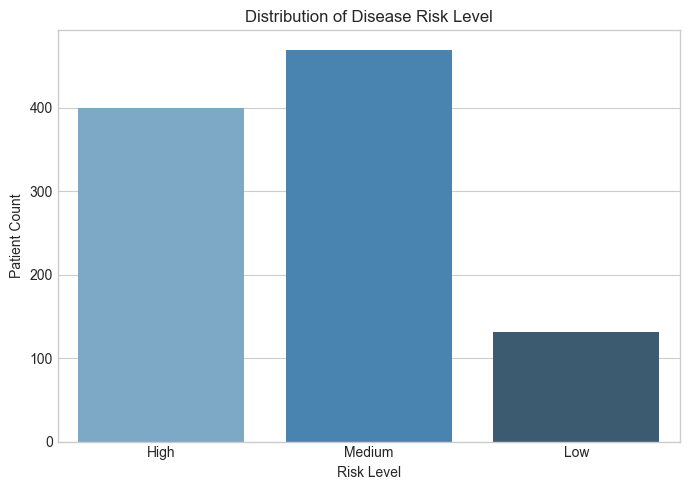

Class counts:
 disease_risk_level
Medium    469
High      400
Low       131
Name: count, dtype: int64
Class percentages (%):
 disease_risk_level
Medium    46.9
High      40.0
Low       13.1
Name: proportion, dtype: float64


In [16]:
plt.figure(figsize=(7, 5))
sns.countplot(data=data, x="disease_risk_level", palette="Blues_d")
plt.title("Distribution of Disease Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Patient Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distribution.png", dpi=300)
plt.show()

vc = data["disease_risk_level"].value_counts()
vp = data["disease_risk_level"].value_counts(normalize=True) * 100
print("Class counts:\n", vc)
print("Class percentages (%):\n", vp.round(2))


### 4.3 Numerical Feature Distributions

The histograms show the range and spread of the main numerical attributes. Several measures, especially blood sugar, cholesterol, age, and BMI, have useful variation across the patient population.


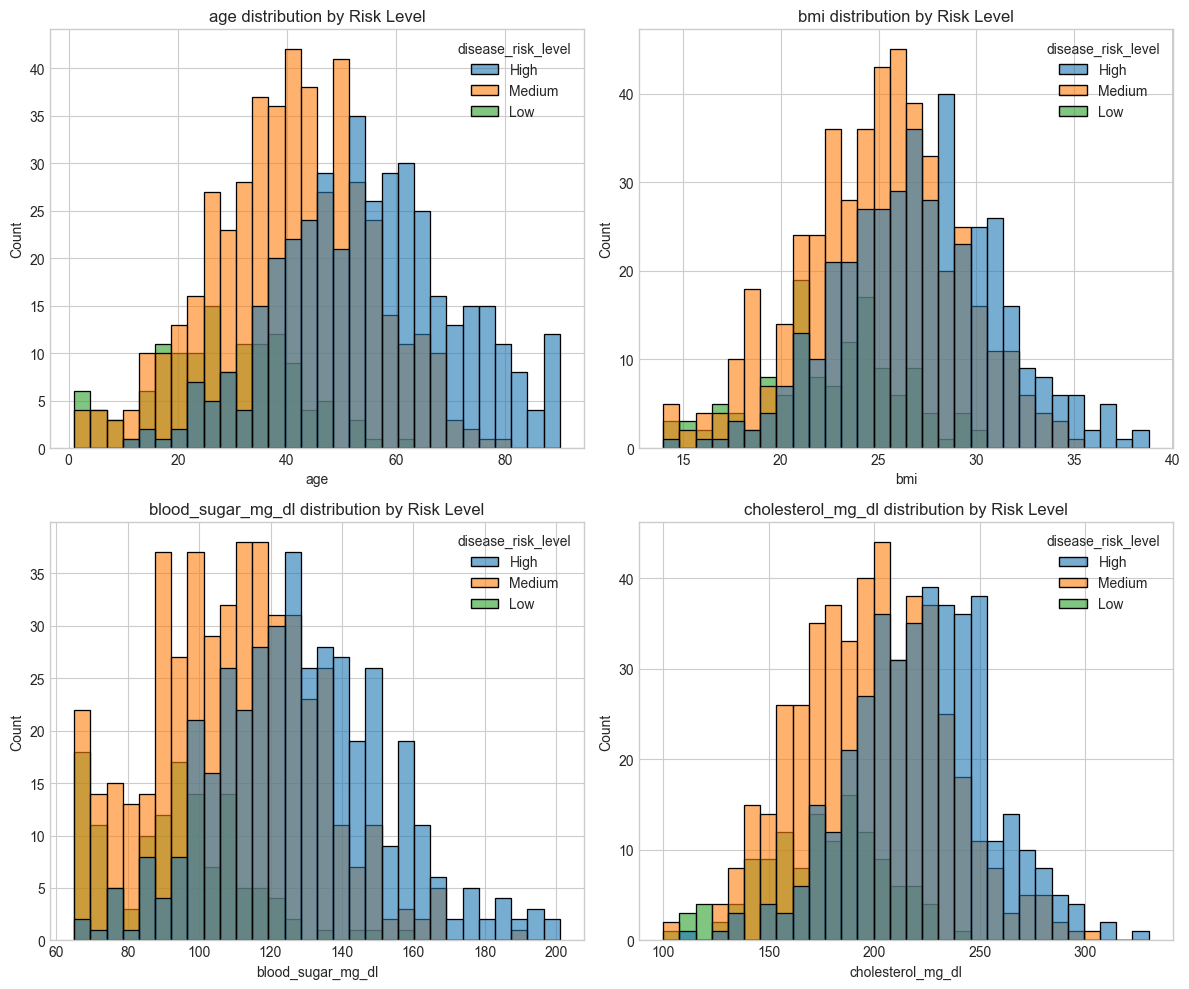

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
cols = [
    "age",
    "bmi",
    "blood_sugar_mg_dl",
    "cholesterol_mg_dl",
]

for ax, col in zip(axes.flatten(), cols):
    if col in data.columns:
        sns.histplot(data=data, x=col, hue="disease_risk_level", kde=False, bins=30, alpha=0.6, ax=ax)
        ax.set_title(f"{col} distribution by Risk Level")
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "numerical_feature_histograms.png", dpi=300)
plt.show()

### 4.4 Boxplot Analysis

The boxplots below compare numerical features across the disease-risk groups.


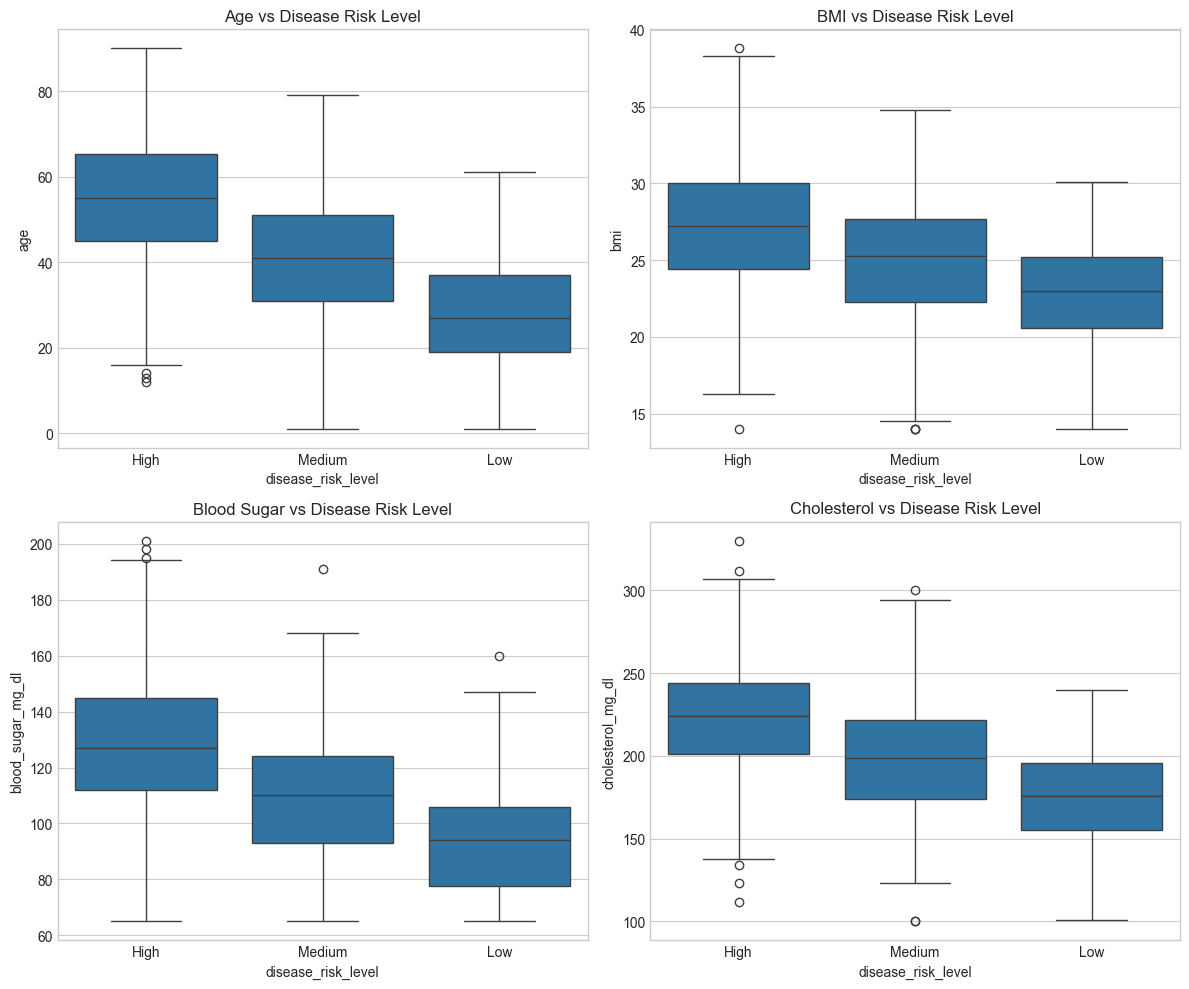

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
cols = [
    ("age", "Age vs Disease Risk Level"),
    ("bmi", "BMI vs Disease Risk Level"),
    ("blood_sugar_mg_dl", "Blood Sugar vs Disease Risk Level"),
    ("cholesterol_mg_dl", "Cholesterol vs Disease Risk Level"),
]

for ax, (col, title) in zip(axes.flatten(), cols):
    if col in data.columns:
        sns.boxplot(data=data, x="disease_risk_level", y=col, ax=ax, order=None)
        ax.set_title(title)
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "clinical_features_boxplot.png", dpi=300)
plt.show()


### 4.5 Scatterplot Analysis

The blood sugar versus cholesterol scatterplot shows a broad spread across the three risk levels, with higher-risk patients tending to appear in regions with more elevated clinical values. This supports using multiple features together instead of relying on one single measure.


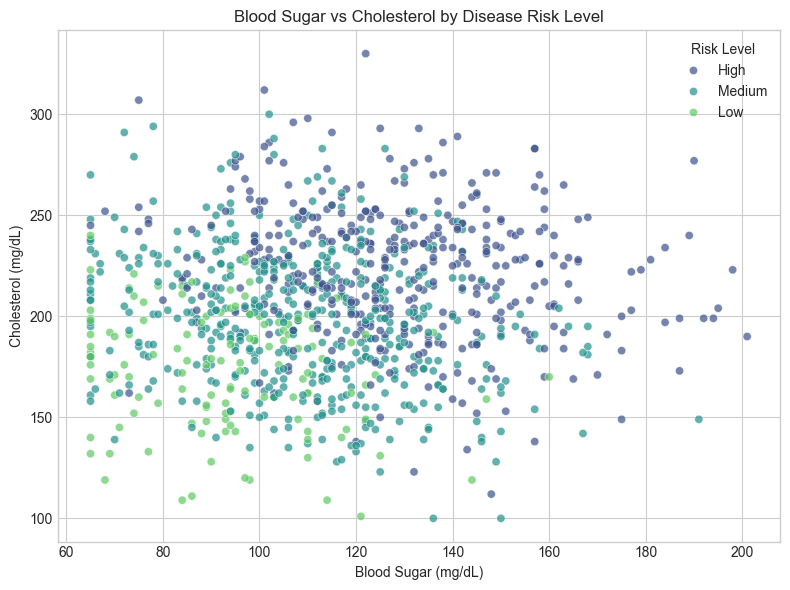

In [19]:
if all(col in data.columns for col in ["blood_sugar_mg_dl", "cholesterol_mg_dl", "disease_risk_level"]):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=data,
        x="blood_sugar_mg_dl",
        y="cholesterol_mg_dl",
        hue="disease_risk_level",
        palette="viridis",
        alpha=0.7,
    )
    plt.title("Blood Sugar vs Cholesterol by Disease Risk Level")
    plt.xlabel("Blood Sugar (mg/dL)")
    plt.ylabel("Cholesterol (mg/dL)")
    plt.legend(title="Risk Level")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "blood_sugar_vs_cholesterol_scatter.png", dpi=300)
    plt.show()
else:
    print("Required columns for scatterplot are not available in the dataset.")

### 4.6 Correlation Analysis

The heatmap shows that the numerical features are not all strongly correlated. This is useful because it suggests that multiple clinically relevant variables contribute to the model rather than one dominant redundant variable.


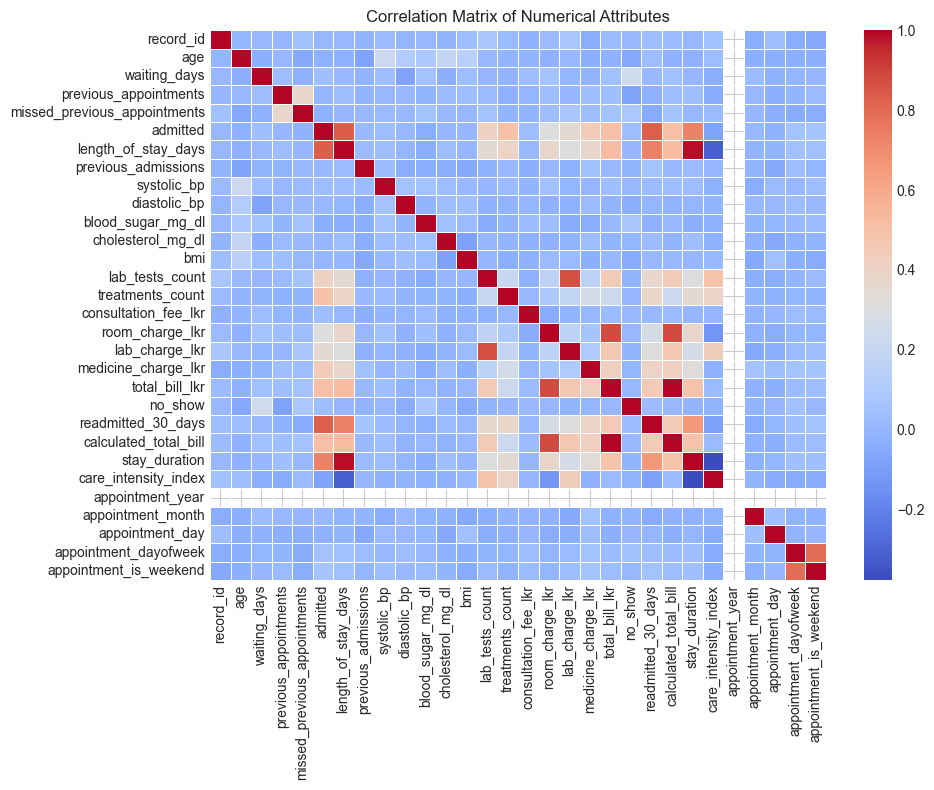

In [20]:
numeric_df = data.select_dtypes(include=[np.number]).copy()
exclude_cols = {"disease_risk_encoded"}
for c in list(exclude_cols):
    if c in numeric_df.columns:
        numeric_df = numeric_df.drop(columns=c)

corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Attributes")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=300)
plt.show()


### 4.7 Categorical Pattern Analysis

The category plots show how patient groups differ in disease-risk distribution across variables such as gender, department, blood group, room type, payment status, and admission status.


Categorical columns available for simple analysis: ['gender', 'diagnosis', 'department', 'blood_group', 'room_type', 'payment_status', 'admitted']


disease_risk_level,High,Low,Medium
gender,,,
Female,41.082164,13.426854,45.490982
Male,38.922156,12.774451,48.303393


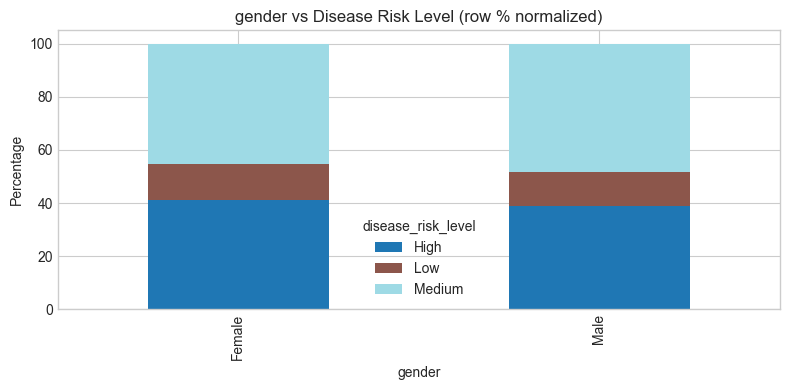

disease_risk_level,High,Low,Medium
diagnosis,,,
Asthma,39.130435,14.130435,46.739130
Back Pain,33.653846,18.269231,48.076923
Chest Pain,35.632184,10.344828,54.022989
Diabetes,60.824742,3.092784,36.082474
Fever,34.579439,22.429907,42.990654
Fracture,42.307692,12.500000,45.192308
Hypertension,32.584270,12.359551,55.056180
Kidney Infection,37.623762,14.851485,47.524752
Migraine,39.423077,10.576923,50.000000


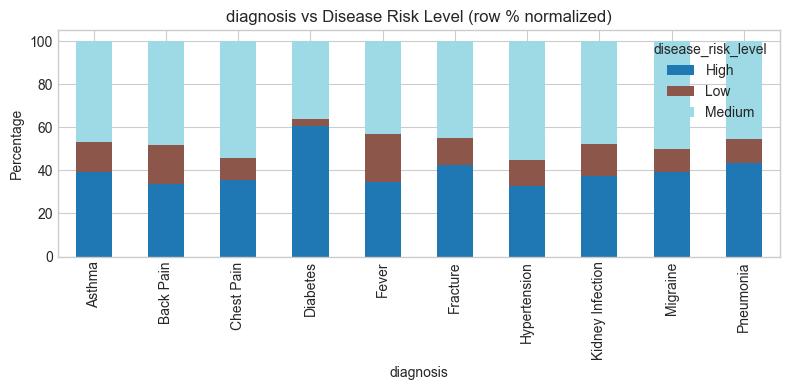

disease_risk_level,High,Low,Medium
department,,,
Cardiology,43.037975,7.594937,49.367089
General Medicine,44.654088,11.949686,43.396226
Laboratory Services,43.103448,13.793103,43.103448
Neurology,36.486486,13.513514,50.000000
Orthopedics,31.205674,21.276596,47.517730
Pediatrics,43.478261,10.869565,45.652174
Radiology,37.857143,13.571429,48.571429


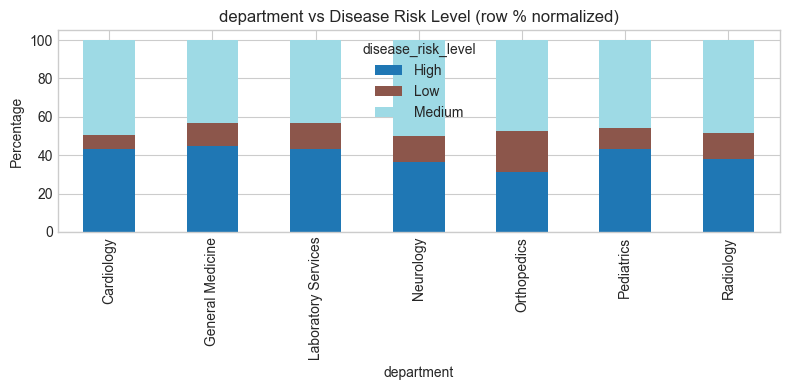

disease_risk_level,High,Low,Medium
blood_group,,,
A+,40.000000,12.500000,47.500000
A-,41.481481,10.370370,48.148148
AB+,45.081967,17.213115,37.704918
AB-,32.352941,15.441176,52.205882
B+,35.606061,15.151515,49.242424
B-,42.857143,12.500000,44.642857
O+,43.518519,7.407407,49.074074
O-,40.740741,13.333333,45.925926


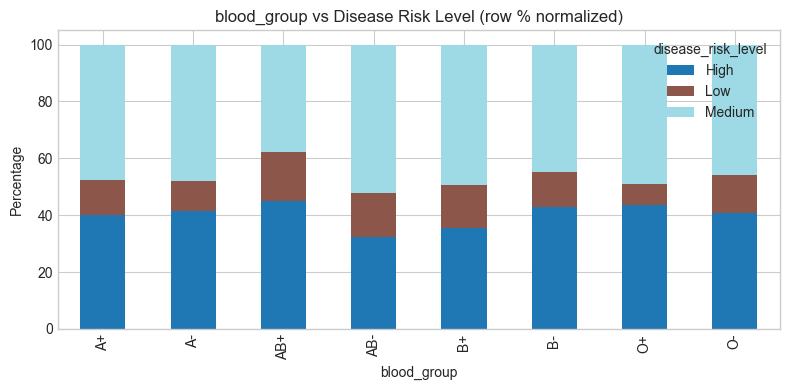

disease_risk_level,High,Low,Medium
room_type,,,
General Ward,53.846154,15.384615,30.769231
ICU,33.333333,11.111111,55.555556
None,39.514349,13.024283,47.461369
Private Room,33.333333,12.121212,54.545455


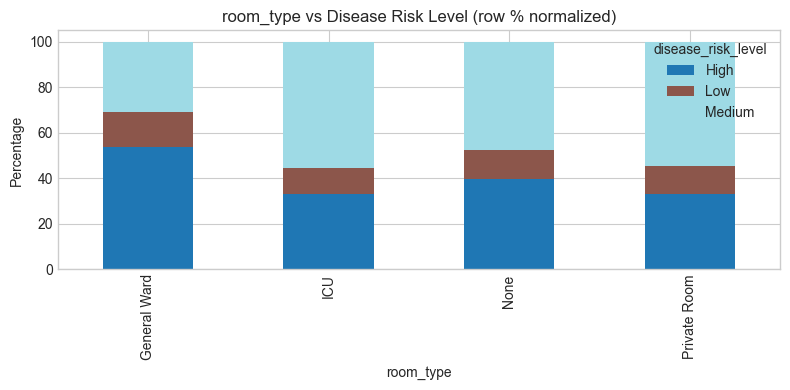

disease_risk_level,High,Low,Medium
payment_status,,,
Paid,38.922156,13.173653,47.904192
Partially Paid,40.833333,14.166667,45.000000
Unpaid,42.924528,12.264151,44.811321


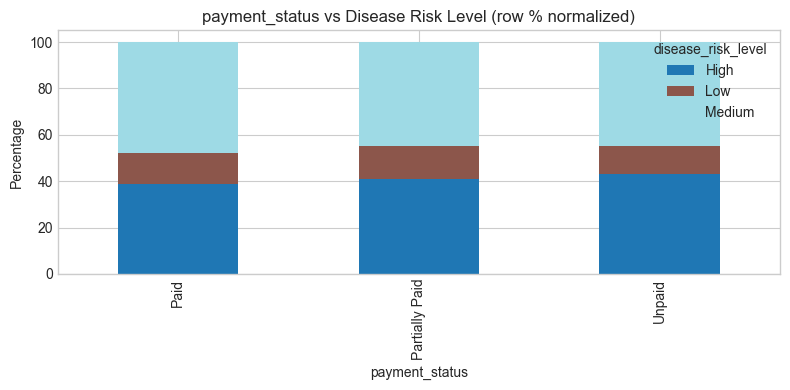

disease_risk_level,High,Low,Medium
admitted,,,
0,39.850746,12.835821,47.313433
1,40.303030,13.636364,46.060606


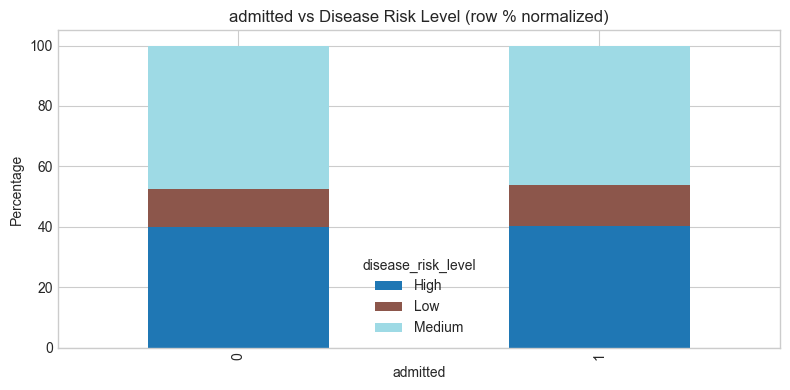

In [21]:
cat_candidates = ["gender", "diagnosis", "department", "blood_group", "room_type", "payment_status", "admitted"]
available = [c for c in cat_candidates if c in data.columns]
print("Categorical columns available for simple analysis:", available)

for c in available:
    ct = pd.crosstab(data[c], data["disease_risk_level"], normalize="index") * 100
    display(ct.head(10))
    fig, ax = plt.subplots(figsize=(8, 4))
    ct.plot(kind="bar", stacked=True, colormap="tab20", legend=True, ax=ax)
    ax.set_title(f"{c} vs Disease Risk Level (row % normalized)")
    ax.set_ylabel("Percentage")
    ax.set_xlabel(c)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{c}_vs_disease_risk_level.png", dpi=300)
    plt.show()


### 4.8 EDA Findings

The dataset is moderately imbalanced, with Medium risk as the most common category and Low risk as the least common. The numerical plots suggest that age, blood pressure, blood sugar, cholesterol, and BMI differ across the risk groups, while the scatterplot indicates that high clinical measurements often align with higher disease risk. Extreme values are kept unless there is clear evidence they are erroneous, because clinically plausible outliers can still reflect real patient conditions.


## Task 05: Machine Learning Model Development

This task covers training, cross-validation and hyperparameter tuning for the selected classifiers.


### 5.1 Model Training and Cross-Validation

Four models are trained and compared using 5-fold stratified cross-validation with Macro F1 as the evaluation metric. Trained pipelines are stored for later evaluation.


In [22]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "Support Vector Machine": SVC(probability=True, random_state=42),
}

trained_pipelines = {}
cv_results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
    trained_pipelines[name] = pipe.fit(X_train, y_train)
    cv_results[name] = {
        "cv_f1_macro_mean": scores.mean(),
        "cv_f1_macro_std": scores.std(),
    }
    print(f"{name} - CV F1 Macro: {scores.mean():.4f} (+/- {scores.std():.4f})")


Logistic Regression - CV F1 Macro: 0.9120 (+/- 0.0329)
Decision Tree - CV F1 Macro: 0.6442 (+/- 0.0315)
Random Forest - CV F1 Macro: 0.6300 (+/- 0.0326)
Support Vector Machine - CV F1 Macro: 0.7537 (+/- 0.0457)


### 5.2 Random Forest Hyperparameter Optimization

GridSearchCV tests combinations of number of trees, maximum depth, minimum samples split, and minimum samples leaf and selects the combination with the best cross-validated Macro F1 using only the training data.


In [23]:
rf_param_grid = {
    "classifier__n_estimators": [200, 300],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],
}
rf_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))])
rf_grid = GridSearchCV(rf_pipe, rf_param_grid, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=0)
print("Starting GridSearchCV for Random Forest (this may take a while)...")
rf_grid.fit(X_train, y_train)
print("Random Forest best params:", rf_grid.best_params_)
print("Random Forest best CV F1 Macro:", rf_grid.best_score_)

trained_pipelines["Random Forest (Tuned)"] = rf_grid.best_estimator_
cv_results["Random Forest (Tuned)"] = {
    "cv_f1_macro_mean": rf_grid.best_score_,
    "cv_f1_macro_std": None,
}


Starting GridSearchCV for Random Forest (this may take a while)...
Random Forest best params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Random Forest best CV F1 Macro: 0.6369557550452244


## Task 06: Model Evaluation

The models are evaluated on the held-out test set using accuracy, macro precision, macro recall, macro F1, and a confusion matrix. Macro F1 is important because the classes are not perfectly balanced and a model that performs well only on the majority class is not necessarily the best classifier.


### 6.1 Performance Evaluation Metrics & Comparison Table

The model comparison table shows each model’s performance on the test set. The best model is selected using the highest macro F1 rather than by accuracy alone, because macro F1 better reflects performance across all three disease-risk classes.


Saved model comparison to ..\outputs\metrics\model_comparison.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_23204\3781307076.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y="F1_Macro", data=results_df.reset_index(), palette="magma")


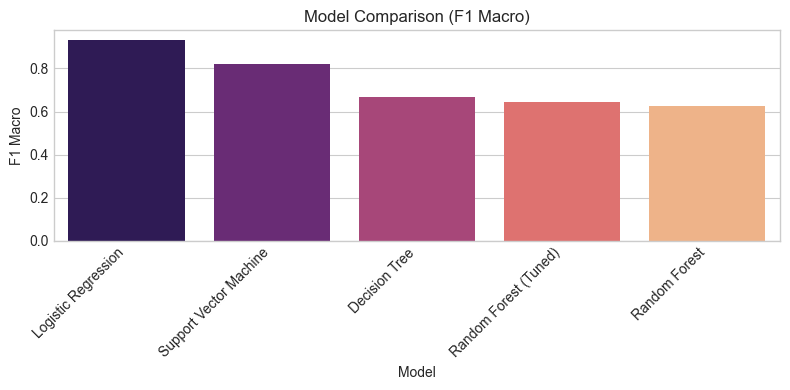

,Accuracy,Precision_Macro,Recall_Macro,F1_Macro,Precision_Weighted,Recall_Weighted,F1_Weighted,CV_F1_Macro_Mean,CV_F1_Macro_Std
Logistic Regression,0.945,0.939728,0.922034,0.930321,0.945123,0.945,0.944753,0.911991,0.032862
Support Vector Machine,0.885,0.926953,0.784875,0.820686,0.899731,0.885,0.876444,0.753717,0.045655
Decision Tree,0.685,0.667324,0.667096,0.666193,0.687917,0.685,0.685233,0.644186,0.031503
Random Forest (Tuned),0.785,0.876108,0.633552,0.643719,0.830385,0.785,0.756843,0.636956,NaN
Random Forest,0.785,0.886826,0.623036,0.626193,0.842613,0.785,0.752310,0.630012,0.032645


In [24]:
results = {}
for name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)

    prec_w = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec_w = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1_w = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results[name] = {
        "Accuracy": acc,
        "Precision_Macro": prec_macro,
        "Recall_Macro": rec_macro,
        "F1_Macro": f1_macro,
        "Precision_Weighted": prec_w,
        "Recall_Weighted": rec_w,
        "F1_Weighted": f1_w,
    }

results_df = pd.DataFrame(results).T
results_df["CV_F1_Macro_Mean"] = results_df.index.map(lambda n: cv_results.get(n, {}).get("cv_f1_macro_mean"))
results_df["CV_F1_Macro_Std"] = results_df.index.map(lambda n: cv_results.get(n, {}).get("cv_f1_macro_std"))
results_df = results_df.sort_values(by="F1_Macro", ascending=False)

results_df.to_csv(METRICS_DIR / "model_comparison.csv")
print("Saved model comparison to", METRICS_DIR / "model_comparison.csv")

plt.figure(figsize=(8, 4))
sns.barplot(x=results_df.index, y="F1_Macro", data=results_df.reset_index(), palette="magma")
plt.title("Model Comparison (F1 Macro)")
plt.ylabel("F1 Macro")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_f1_macro.png", dpi=300)
plt.show()

display(results_df)


### 6.2 Confusion Matrices for All Models

The following confusion matrices show model predictions on the test set for each trained pipeline using the Low/Medium/High class labels.


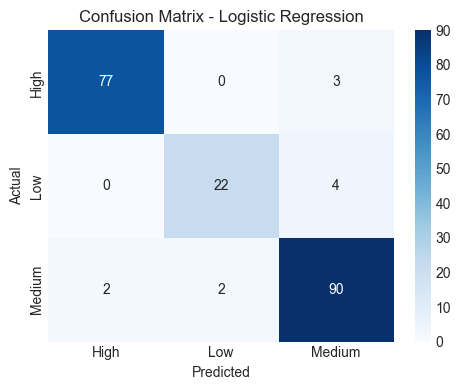

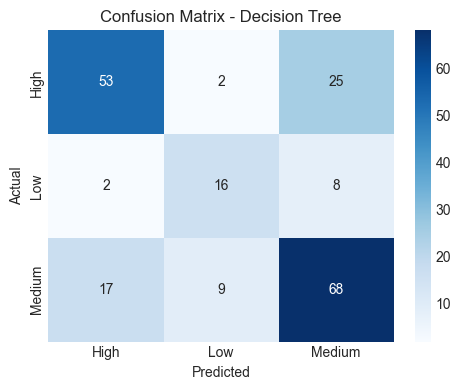

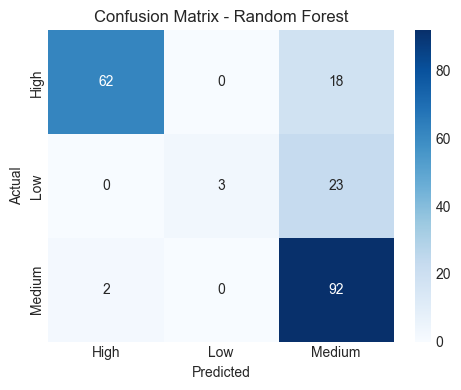

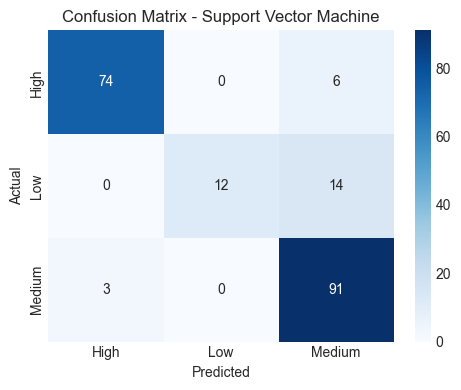

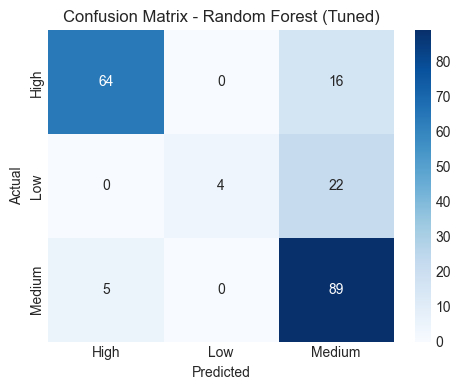

In [25]:
for name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f"Confusion Matrix - {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()


### 6.3 Best Model Selection and Detailed Classification Report

The best model is selected using the highest test Macro F1. Macro F1 gives equal importance to Low, Medium, and High classes, which is useful because the classes are not perfectly balanced. The detailed classification report is used to inspect class-level Precision, Recall, and F1 to understand where the model performs well or poorly.


Best Performing Model: Logistic Regression
Selection criterion: Highest Macro F1 on the hold-out test set
Best Macro F1: 0.9303
Runner-up model: Support Vector Machine (F1 Macro = 0.8207)
Model performance summary:


Accuracy              0.9450
Precision_Macro       0.9397
Recall_Macro          0.9220
F1_Macro              0.9303
Precision_Weighted    0.9451
Recall_Weighted       0.9450
F1_Weighted           0.9448
Name: Logistic Regression, dtype: float64


Detailed Classification Report:
              precision    recall  f1-score   support

        High       0.97      0.96      0.97        80
         Low       0.92      0.85      0.88        26
      Medium       0.93      0.96      0.94        94

    accuracy                           0.94       200
   macro avg       0.94      0.92      0.93       200
weighted avg       0.95      0.94      0.94       200


Model successfully serialized to ..\models\best_disease_risk_model.joblib

Confusion Matrix:


,High,Low,Medium
High,77,0,3
Low,0,22,4
Medium,2,2,90


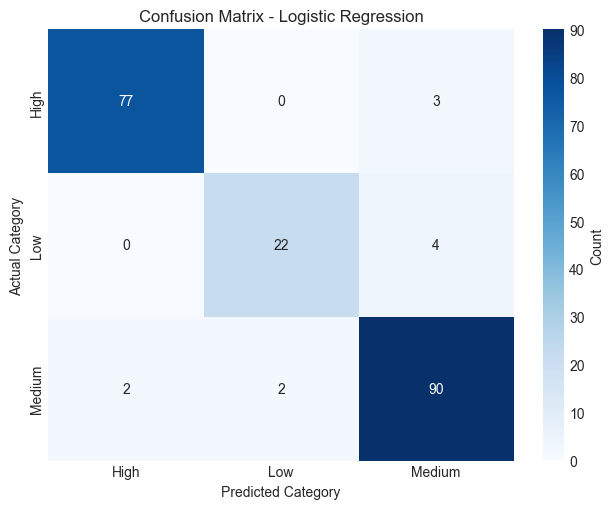


Per-class summary:


,Class,precision,recall,f1-score,support
0,High,0.9747,0.9625,0.9686,80.0
1,Low,0.9167,0.8462,0.8800,26.0
2,Medium,0.9278,0.9574,0.9424,94.0


In [26]:
if "results_df" not in globals():
    if "trained_pipelines" not in globals():
        raise NameError("results_df is not defined. Please run the model training and evaluation cells in Task 05 and 6.1 first.")
    if not {"X_test", "y_test"}.issubset(globals()):
        raise NameError("Test data is not available. Please run the train-test split cell before executing this section.")

    results = {}
    for name, pipe in trained_pipelines.items():
        y_pred = pipe.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        prec_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
        rec_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
        f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)

        prec_w = precision_score(y_test, y_pred, average="weighted", zero_division=0)
        rec_w = recall_score(y_test, y_pred, average="weighted", zero_division=0)
        f1_w = f1_score(y_test, y_pred, average="weighted", zero_division=0)

        results[name] = {
            "Accuracy": acc,
            "Precision_Macro": prec_macro,
            "Recall_Macro": rec_macro,
            "F1_Macro": f1_macro,
            "Precision_Weighted": prec_w,
            "Recall_Weighted": rec_w,
            "F1_Weighted": f1_w,
        }

    results_df = pd.DataFrame(results).T
    if "cv_results" in globals():
        results_df["CV_F1_Macro_Mean"] = results_df.index.map(lambda n: cv_results.get(n, {}).get("cv_f1_macro_mean"))
        results_df["CV_F1_Macro_Std"] = results_df.index.map(lambda n: cv_results.get(n, {}).get("cv_f1_macro_std"))
    results_df = results_df.sort_values(by="F1_Macro", ascending=False)

if "label_encoder" not in globals():
    raise NameError("label_encoder is not defined. Please run the target encoding step before this section.")

best_model_name = results_df["F1_Macro"].idxmax()
best_pipeline = trained_pipelines[best_model_name]
best_metrics = results_df.loc[best_model_name, [
    "Accuracy",
    "Precision_Macro",
    "Recall_Macro",
    "F1_Macro",
    "Precision_Weighted",
    "Recall_Weighted",
    "F1_Weighted",
]].round(4)

runner_up_name = results_df.drop(index=best_model_name)["F1_Macro"].idxmax()
runner_up_f1 = results_df.loc[runner_up_name, "F1_Macro"]

print("=" * 80)
print(f"Best Performing Model: {best_model_name}")
print(f"Selection criterion: Highest Macro F1 on the hold-out test set")
print(f"Best Macro F1: {best_metrics['F1_Macro']:.4f}")
print(f"Runner-up model: {runner_up_name} (F1 Macro = {runner_up_f1:.4f})")
print("=" * 80)
print("Model performance summary:")
display(best_metrics)

# Generate predictions for the selected model

y_pred_best = best_pipeline.predict(X_test)
class_labels = list(label_encoder.classes_)

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=class_labels, zero_division=0))

# Save the best model and results
joblib.dump(best_pipeline, MODELS_DIR / "best_disease_risk_model.joblib")
print(f"\nModel successfully serialized to {MODELS_DIR / 'best_disease_risk_model.joblib'}")

# Confusion matrix for the best-performing model
cm = confusion_matrix(y_test, y_pred_best, labels=np.arange(len(class_labels)))
cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)
print("\nConfusion Matrix:")
display(cm_df)

plt.figure(figsize=(6.5, 5.2))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
    cbar_kws={"label": "Count"},
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.ylabel("Actual Category")
plt.xlabel("Predicted Category")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "best_model_confusion_matrix.png", dpi=300)
plt.show()

# Optional summary of class-wise performance for transparency
class_report = classification_report(
    y_test,
    y_pred_best,
    target_names=class_labels,
    output_dict=True,
    zero_division=0,
)
class_summary = pd.DataFrame(class_report).T.drop(index=["accuracy", "macro avg", "weighted avg"]).reset_index()
class_summary = class_summary.rename(columns={"index": "Class"})
print("\nPer-class summary:")
display(class_summary[["Class", "precision", "recall", "f1-score", "support"]].round(4))


## Task 07: Explainable AI (XAI) Analysis

Permutation feature importance is used as the explainable AI method for the selected best model. It measures how much the model’s macro F1 changes when each feature is randomly shuffled, which makes the variable importance easy to interpret.


### 7.1 Permutation Feature Importance Analysis

The strongest features in the final model are blood sugar, cholesterol, age, BMI, previous admissions, and systolic blood pressure. The saved permutation importance results show the largest drops in macro F1 when these variables are shuffled, which means the model relies on them to maintain predictive performance. Permutation importance measures how much the model score decreases when one feature is randomly shuffled while all other features remain unchanged. A larger drop means the feature carries useful predictive information for the disease-risk task. This improves model transparency because the important variables can be checked directly from the out-of-sample performance, rather than relying only on a single coefficient value or a visual impression. Global feature importance is still limited: it explains which variables matter overall, but it does not fully explain how an individual patient-specific prediction is formed.


Computing permutation importance on the test set...
Saved permutation importance to ..\outputs\metrics\feature_importance.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_23204\4103067586.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance_mean", y="feature", data=perm_df.head(top_n), palette="viridis")


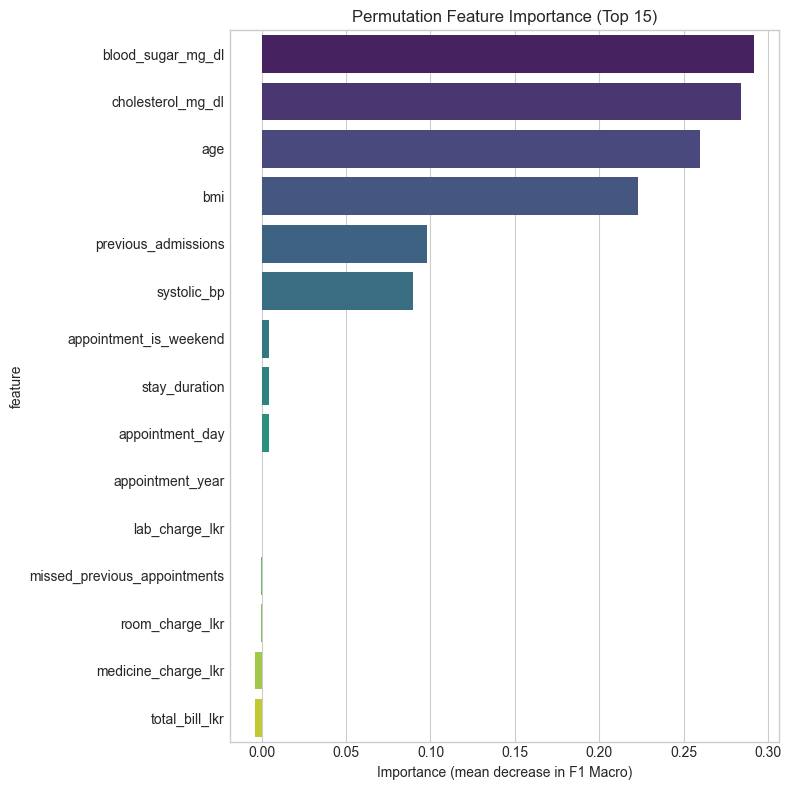

In [27]:
print("Computing permutation importance on the test set...")
perm_res = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_res.importances_mean,
    "importance_std": perm_res.importances_std,
}).sort_values(by="importance_mean", ascending=False)

perm_df.to_csv(METRICS_DIR / "feature_importance.csv", index=False)
print("Saved permutation importance to", METRICS_DIR / "feature_importance.csv")

top_n = 15
plt.figure(figsize=(8, min(0.4 * top_n + 2, 12)))
sns.barplot(x="importance_mean", y="feature", data=perm_df.head(top_n), palette="viridis")
plt.title(f"Permutation Feature Importance (Top {top_n})")
plt.xlabel("Importance (mean decrease in F1 Macro)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "permutation_feature_importance.png", dpi=300)
plt.show()


### 7.2 Prediction Reasoning and Transparency

- The preprocessing pipeline transforms patient inputs (median imputation + scaling for numeric features; most-frequent imputation + one-hot encoding for categorical features).
- The selected classifier uses these transformed inputs to predict Low, Medium, or High disease risk.
- Permutation importance shows which original variables most affect overall predictive performance; current important variables often include blood sugar, cholesterol, age, BMI, previous admissions, and systolic blood pressure if they appear near the top after execution.
- Permutation importance is a global explanation and does not prove that one feature alone caused an individual prediction; it only measures how shuffling that feature affects model performance.


In [28]:
example_idx = X_test.index[0]
example_row = X_test.loc[[example_idx]].copy()
pred_numeric = best_pipeline.predict(example_row)
pred_label = label_encoder.inverse_transform(pred_numeric)[0]
print("Selected example row index:", example_idx)
display(example_row)
print("Predicted disease risk level:", pred_label)
if hasattr(best_pipeline, "predict_proba") or hasattr(best_pipeline.named_steps["classifier"], "predict_proba"):
    try:
        probs = best_pipeline.predict_proba(example_row)
        print("Class probabilities:")
        display(pd.Series(probs[0], index=label_encoder.classes_))
    except Exception:
        print("Model does not support predict_proba for this pipeline.")

Selected example row index: 199


,age,gender,blood_group,department,diagnosis,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,calculated_total_bill,stay_duration,care_intensity_index,appointment_year,appointment_month,appointment_day,appointment_dayofweek,appointment_is_weekend
199,45,Female,O-,Radiology,Fracture,7,1,0,Completed,0,None,0,1,127,64,92,196,22.4,2,1,1500,0,3600,1237,6337,Unpaid,Cash,6337,1,3.0,2025,3,11,1,0


Predicted disease risk level: Medium
Class probabilities:


High      0.000211
Low       0.049013
Medium    0.950777
dtype: float64

### 7.3 Ethical Implications

The model should be treated as a decision-support tool rather than a replacement for a healthcare professional. Patient privacy, possible bias, class imbalance, and incorrect predictions must be considered when interpreting the results. Human supervision remains necessary, and the predictions should be used to support clinical review rather than to make independent medical decisions.
